In [ ]:
import pandas as pd
import numpy as np

# -----------------------------------
# CONFIGURATION
# -----------------------------------
years = 3
interval_minutes = 5
building_name = "MegaCityMall"

# -----------------------------------
# Time Index
# -----------------------------------
timestamps = pd.date_range(
    start="2023-01-01",
    periods=int((365*years*24*60)/interval_minutes),
    freq=f"{interval_minutes}min"
)

df = pd.DataFrame({"Timestamp": timestamps})
df["Building"] = building_name

df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Month"] = df["Timestamp"].dt.month
df["Year"] = df["Timestamp"].dt.year

# -----------------------------------
# Weather Simulation
# -----------------------------------
daily = 6*np.sin(2*np.pi*df.index/(24*60/interval_minutes))
seasonal = 10*np.sin(2*np.pi*df.index/(365*24*60/interval_minutes))
df["AmbientTemp"] = 32 + daily + seasonal

df["Humidity"] = 65 + 15*np.sin(2*np.pi*df.index/(48*60/interval_minutes))

# Wet Bulb Temperature
df["WBT"] = df["AmbientTemp"] * np.arctan(0.151977*np.sqrt(df["Humidity"]+8.313659))

# -----------------------------------
# Occupancy Pattern (Mall)
# -----------------------------------
df["Occupancy"] = 0.05
df.loc[(df["Hour"]>=10)&(df["Hour"]<=22),"Occupancy"] = 0.85
df.loc[df["DayOfWeek"]>=5,"Occupancy"] += 0.15

df["Occupancy"] += np.random.uniform(-0.05,0.05,len(df))
df["Occupancy"] = df["Occupancy"].clip(0.05,1.0)

# -----------------------------------
# Cooling Load (TR)
# -----------------------------------
building_factor = 15
df["TR"] = (df["AmbientTemp"]-23)*df["Occupancy"]*building_factor
df["TR"] = df["TR"].clip(lower=120)

# -----------------------------------
# Chiller Performance
# -----------------------------------
base_efficiency = 0.70
temp_effect = (df["AmbientTemp"]-30)*0.007
degradation = np.linspace(0,0.06,len(df))

df["iKW_TR"] = base_efficiency + temp_effect + degradation

# Part Load Ratio
df["PLR"] = df["TR"] / df["TR"].max()

# COP
df["COP"] = 3.517 / df["iKW_TR"]

# -----------------------------------
# Power & Energy
# -----------------------------------
df["kW"] = df["TR"] * df["iKW_TR"]
df["kWh"] = df["kW"] * (interval_minutes/60)

# -----------------------------------
# Equipment Aging
# -----------------------------------
df["EquipmentAgeFactor"] = degradation*10

# Maintenance Score (declines over time)
df["MaintenanceScore"] = 100 - (degradation*100)

# -----------------------------------
# Fault Injection
# -----------------------------------
fault_index = np.random.choice(len(df), 200)
df.loc[fault_index, "kW"] *= 1.4
df["FaultFlag"] = 0
df.loc[fault_index, "FaultFlag"] = 1

# -----------------------------------
# Save
# -----------------------------------
df.to_csv("large_mall_dataset_3years_5min.csv", index=False)

print("Large mall dataset generated successfully!")
print("Total rows:", len(df))


Large mall dataset generated successfully!
Total rows: 315360


In [2]:
df.count()

Timestamp             315360
Building              315360
Hour                  315360
DayOfWeek             315360
Month                 315360
Year                  315360
AmbientTemp           315360
Humidity              315360
WBT                   315360
Occupancy             315360
TR                    315360
iKW_TR                315360
PLR                   315360
COP                   315360
kW                    315360
kWh                   315360
EquipmentAgeFactor    315360
MaintenanceScore      315360
FaultFlag             315360
dtype: int64

In [3]:
df.describe()

,Timestamp,Hour,DayOfWeek,Month,Year,AmbientTemp,Humidity,WBT,Occupancy,TR,iKW_TR,PLR,COP,kW,kWh,EquipmentAgeFactor,MaintenanceScore,FaultFlag
count,315360,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000,315360.000000
mean,2024-07-01 11:57:29.999999232,11.500000,2.998174,6.516895,2023.999087,32.000000,65.008721,29.206752,0.528306,133.460771,0.744000,0.404445,4.754720,99.869543,8.320306,0.300000,97.000000,0.000634
min,2023-01-01 00:00:00,0.000000,0.000000,1.000000,2023.000000,16.000000,50.000000,14.029444,0.050000,120.000000,0.616929,0.363653,4.037557,74.031478,6.169290,0.000000,94.000000,0.000000
25%,2023-10-01 17:58:45,5.750000,1.000000,4.000000,2023.000000,25.774274,54.393398,23.443680,0.076225,120.000000,0.701811,0.363653,4.473479,84.221878,7.018112,0.150000,95.500000,0.000000
50%,2024-07-01 11:57:30,11.500000,3.000000,7.000000,2024.000000,32.000000,65.000000,29.161387,0.810758,120.000000,0.744000,0.363653,4.727150,90.123387,7.509340,0.300000,97.000000,0.000000
75%,2025-04-01 05:56:15,17.250000,5.000000,10.000000,2025.000000,38.225726,75.606602,34.943314,0.875379,120.000000,0.786189,0.363653,5.011320,99.825701,8.316995,0.450000,98.500000,0.000000
max,2025-12-30 23:55:00,23.000000,6.000000,12.000000,2025.000000,48.000000,80.000000,45.541857,1.000000,329.984566,0.871071,1.000000,5.700818,318.572676,23.365993,0.600000,100.000000,1.000000
std,NaN,6.922198,2.002284,3.446589,0.815938,8.246224,10.606615,7.616687,0.397993,32.171619,0.056442,0.097494,0.364789,28.435905,2.367236,0.173206,1.732059,0.025175


Dataset Shape: (315360, 19)

Columns:
 Index(['Timestamp', 'Building', 'Hour', 'DayOfWeek', 'Month', 'Year',
       'AmbientTemp', 'Humidity', 'WBT', 'Occupancy', 'TR', 'iKW_TR', 'PLR',
       'COP', 'kW', 'kWh', 'EquipmentAgeFactor', 'MaintenanceScore',
       'FaultFlag'],
      dtype='object')

Missing Values:
 Timestamp             0
Building              0
Hour                  0
DayOfWeek             0
Month                 0
Year                  0
AmbientTemp           0
Humidity              0
WBT                   0
Occupancy             0
TR                    0
iKW_TR                0
PLR                   0
COP                   0
kW                    0
kWh                   0
EquipmentAgeFactor    0
MaintenanceScore      0
FaultFlag             0
dtype: int64


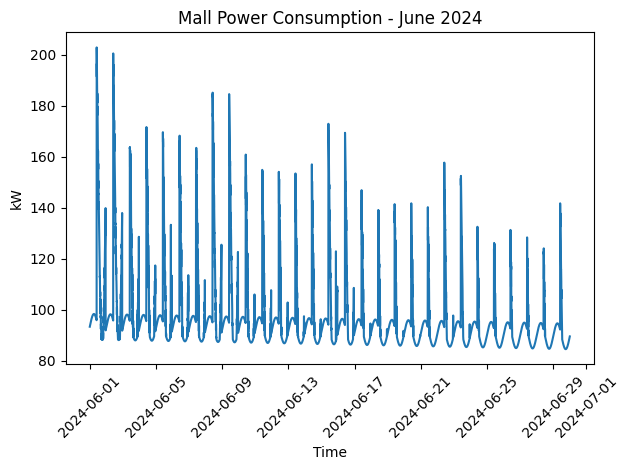

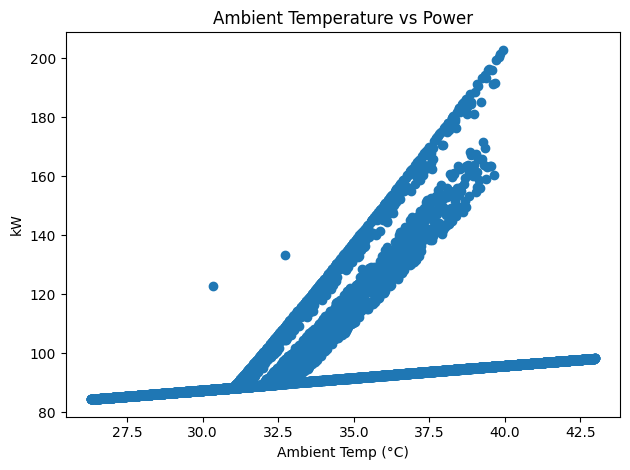

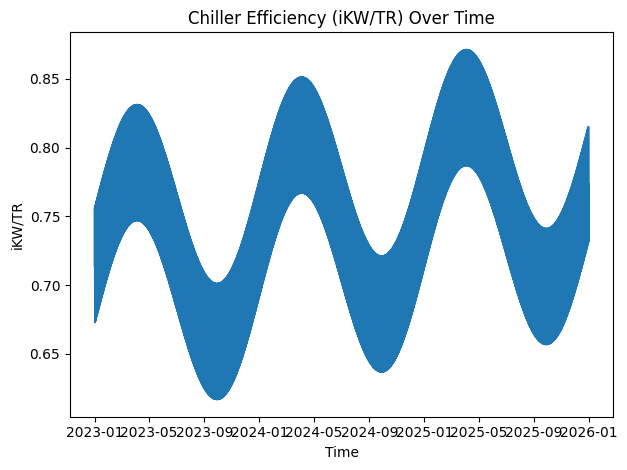

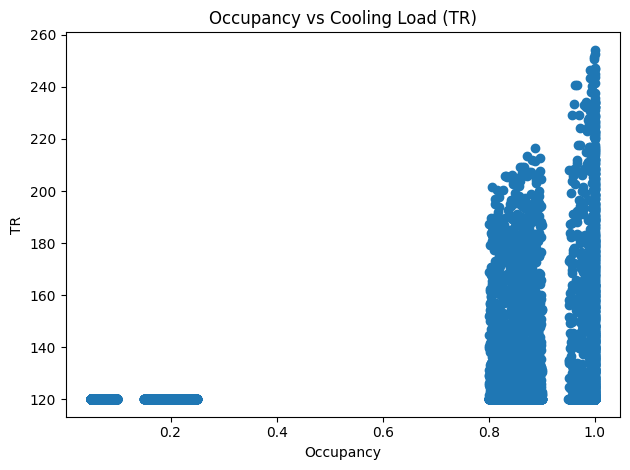

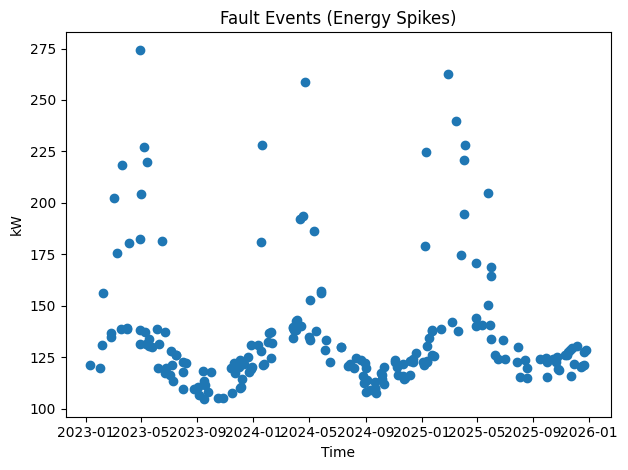

EDA Validation Completed Successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Load Dataset
# -----------------------------------
df = pd.read_csv("large_mall_dataset_3years_5min.csv", parse_dates=["Timestamp"])

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

# -----------------------------------
# Sample 1 Month for Visualization
# -----------------------------------
sample = df[(df["Timestamp"] >= "2024-06-01") & 
            (df["Timestamp"] <= "2024-06-30")]

# -----------------------------------
# 1. Load Profile
# -----------------------------------
plt.figure()
plt.plot(sample["Timestamp"], sample["kW"])
plt.title("Mall Power Consumption - June 2024")
plt.xlabel("Time")
plt.ylabel("kW")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------------
# 2. Ambient Temperature vs kW
# -----------------------------------
plt.figure()
plt.scatter(sample["AmbientTemp"], sample["kW"])
plt.title("Ambient Temperature vs Power")
plt.xlabel("Ambient Temp (°C)")
plt.ylabel("kW")
plt.tight_layout()
plt.show()

# -----------------------------------
# 3. iKW/TR Over Full 3 Years
# -----------------------------------
plt.figure()
plt.plot(df["Timestamp"], df["iKW_TR"])
plt.title("Chiller Efficiency (iKW/TR) Over Time")
plt.xlabel("Time")
plt.ylabel("iKW/TR")
plt.tight_layout()
plt.show()

# -----------------------------------
# 4. Occupancy vs TR
# -----------------------------------
plt.figure()
plt.scatter(sample["Occupancy"], sample["TR"])
plt.title("Occupancy vs Cooling Load (TR)")
plt.xlabel("Occupancy")
plt.ylabel("TR")
plt.tight_layout()
plt.show()

# -----------------------------------
# 5. Fault Visualization
# -----------------------------------
faults = df[df["FaultFlag"] == 1]

plt.figure()
plt.scatter(faults["Timestamp"], faults["kW"])
plt.title("Fault Events (Energy Spikes)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.tight_layout()
plt.show()

print("EDA Validation Completed Successfully!")

In [4]:
print(df.corr(numeric_only=True)[["kW"]]
        .sort_values("kW", ascending=False))

                          kW
kW                  1.000000
kWh                 0.999373
TR                  0.972146
PLR                 0.972146
AmbientTemp         0.525314
WBT                 0.516482
iKW_TR              0.512642
Occupancy           0.249000
MaintenanceScore    0.080174
Year                0.076932
DayOfWeek           0.059774
Hour                0.058993
FaultFlag           0.032287
Humidity            0.000033
EquipmentAgeFactor -0.080174
Month              -0.458508
COP                -0.515711


In [6]:
print(df.columns)
print(df.index)

Index(['Building', 'Hour', 'DayOfWeek', 'Month', 'Year', 'AmbientTemp',
       'Humidity', 'WBT', 'Occupancy', 'TR', 'iKW_TR', 'PLR', 'COP', 'kW',
       'kWh', 'EquipmentAgeFactor', 'MaintenanceScore', 'FaultFlag'],
      dtype='object')
DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 00:05:00',
               '2023-01-01 00:10:00', '2023-01-01 00:15:00',
               '2023-01-01 00:20:00', '2023-01-01 00:25:00',
               '2023-01-01 00:30:00', '2023-01-01 00:35:00',
               '2023-01-01 00:40:00', '2023-01-01 00:45:00',
               ...
               '2025-12-30 23:10:00', '2025-12-30 23:15:00',
               '2025-12-30 23:20:00', '2025-12-30 23:25:00',
               '2025-12-30 23:30:00', '2025-12-30 23:35:00',
               '2025-12-30 23:40:00', '2025-12-30 23:45:00',
               '2025-12-30 23:50:00', '2025-12-30 23:55:00'],
              dtype='datetime64[ns]', name='Timestamp', length=315360, freq=None)


In [9]:
hourly_df = df.select_dtypes(include=["number"]).resample("h").mean()

print(hourly_df.head())
print("Shape:", hourly_df.shape)

                     Hour  DayOfWeek  Month    Year  AmbientTemp   Humidity  \
Timestamp                                                                     
2023-01-01 00:00:00   0.0        6.0    1.0  2023.0    32.719474  65.898758   
2023-01-01 01:00:00   1.0        6.0    1.0  2023.0    34.239623  67.844054   
2023-01-01 02:00:00   2.0        6.0    1.0  2023.0    35.607858  69.740687   
2023-01-01 03:00:00   3.0        6.0    1.0  2023.0    36.731425  71.556206   
2023-01-01 04:00:00   4.0        6.0    1.0  2023.0    37.534244  73.259547   

                           WBT  Occupancy     TR    iKW_TR       PLR  \
Timestamp                                                              
2023-01-01 00:00:00  30.053957   0.193366  120.0  0.719037  0.363653   
2023-01-01 01:00:00  31.663475   0.204432  120.0  0.729681  0.363653   
2023-01-01 02:00:00  33.138794   0.209155  120.0  0.739261  0.363653   
2023-01-01 03:00:00  34.386257   0.205197  120.0  0.747128  0.363653   
2023-01-01 04:

In [10]:
hourly_df["kW_lag1"] = hourly_df["kW"].shift(1)

hourly_df = hourly_df.dropna()

In [11]:
print(hourly_df[["kW", "kW_lag1"]].head())

                            kW    kW_lag1
Timestamp                                
2023-01-01 01:00:00  87.561683  86.284484
2023-01-01 02:00:00  88.711274  87.561683
2023-01-01 03:00:00  89.655345  88.711274
2023-01-01 04:00:00  90.329986  89.655345
2023-01-01 05:00:00  90.689653  90.329986
